<h1>Dataset Used</h1>
<p>The dataset utilised comprises information on 1,207 stocks listed in the US. Time range starts from November 1998 and ends in March 2019 for the sake of the study we will use the data provided by this book but later on we would use a more recent data.</p>
<p>For each point in time, 93 <b>characteristics</b> describe the firms in the sample. These attribute cover a wide range of topics.

<b>Valuation</b> (earnings yields, accounting ratios)
<br>
<b>Profitability and quality</b> (return on equity)
<br>
<b>Momentum and technical analysis</b> (past returns, relative strength index)
<br>
<b>Risk</b> (volatilities)
<br>
<b>Estimates </b> (earnings-per-share)
<br>
<b>volume and liquidity</b> (share turnover).
</p>

In [1]:
import matplotlib.pyplot as plt
import pyreadr
import pandas as pd
import seaborn as sns

In [2]:


result = pyreadr.read_r("../Data/data_ml.RData")
print("Objects found in file:", result.keys())
data_ml = result["data_ml"]

#Convert date column to datetime if it isn't already
data_ml["date"] = pd.to_datetime(data_ml["date"])

#filtering to the textbook range
mask = (data_ml["date"] > "1999-12-31") & (data_ml["date"] < "2019-01-01")
data_ml = data_ml.loc[mask].sort_values(by=["stock_id", "date"]).reset_index(drop=True)

data_ml.head()


Objects found in file: odict_keys(['data_ml'])


,stock_id,date,Advt_12M_Usd,Advt_3M_Usd,Advt_6M_Usd,Asset_Turnover,Bb_Yld,Bv,Capex_Ps_Cf,Capex_Sales,...,Total_Capital,Total_Debt,Total_Debt_Capital,Total_Liabilities_Total_Assets,Vol1Y_Usd,Vol3Y_Usd,R1M_Usd,R3M_Usd,R6M_Usd,R12M_Usd
0,1,2000-01-31,0.41,0.39,0.42,0.19,0.65,0.63,0.5,0.9,...,0.74,0.82,0.88,0.74,0.77,0.68,-0.036,0.196,0.255,1.044
1,1,2000-02-29,0.41,0.39,0.40,0.19,0.81,0.63,0.5,0.9,...,0.74,0.82,0.88,0.74,0.73,0.67,0.263,0.797,0.669,1.192
2,1,2000-03-31,0.40,0.37,0.37,0.20,0.68,0.65,0.5,0.9,...,0.76,0.83,0.87,0.75,0.67,0.66,0.031,0.275,0.419,0.495
3,1,2000-04-30,0.39,0.36,0.37,0.20,0.38,0.65,0.5,0.9,...,0.76,0.83,0.87,0.75,0.63,0.65,0.448,0.042,0.267,0.853
4,1,2000-05-31,0.40,0.42,0.40,0.20,0.60,0.65,0.5,0.9,...,0.76,0.83,0.87,0.75,0.54,0.67,-0.097,-0.071,0.027,0.413


<p>The data has 99 columns and 268446 rows. The first two columns indicate the stock identifier and the date. The next 93 columns are the features. The last four columns are the labels.</p>

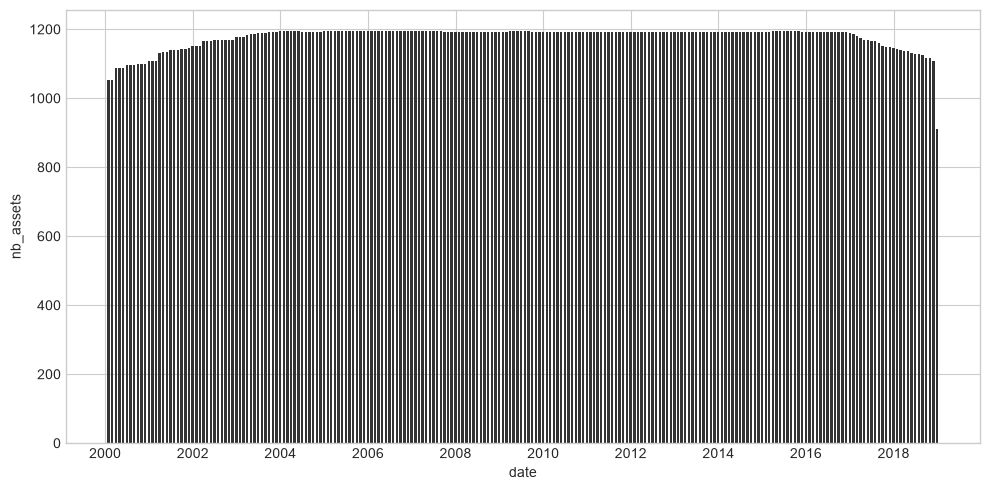

In [3]:
import pandas as pd


# 1. Group by date and count unique assets per date
df_summary = (
    data_ml.groupby("date")["stock_id"]
    .nunique()
    .reset_index(name="nb_assets")
)

# 2. Plot using matplotlib
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df_summary["date"], df_summary["nb_assets"], width=20, color="#333333")
ax.set_xlabel("date")
ax.set_ylabel("nb_assets")

plt.tight_layout()
plt.show()



<p>There are four labels (<b>R1M_Usd, R3M_Usd, R6M_Usd and R12M_Usd</b>) in the dataset: which corresponds to the  1-month, 3-month, 6-month and 12-month future/forward returns of the stocks.</p>

In [4]:
features_col = data_ml[3:95]
#Shorter list of predictors
features_short = data_ml[["Div_Yld", "Eps", "Mkt_Cap_12M_Usd", "Mom_11M_Usd", 
                    "Ocf", "Pb", "Vol1Y_Usd"]]

features_col.head()
features_short.head()

,Div_Yld,Eps,Mkt_Cap_12M_Usd,Mom_11M_Usd,Ocf,Pb,Vol1Y_Usd
0,0.01,0.01,0.52,0.59,0.70,0.21,0.77
1,0.01,0.01,0.52,0.87,0.70,0.21,0.73
2,0.20,0.07,0.51,0.55,0.74,0.15,0.67
3,0.23,0.07,0.51,0.52,0.74,0.15,0.63
4,0.17,0.07,0.52,0.46,0.74,0.15,0.54


<p>The predictors were uniformized, meaning for given feature and time point, the distribution is uniform.</p>

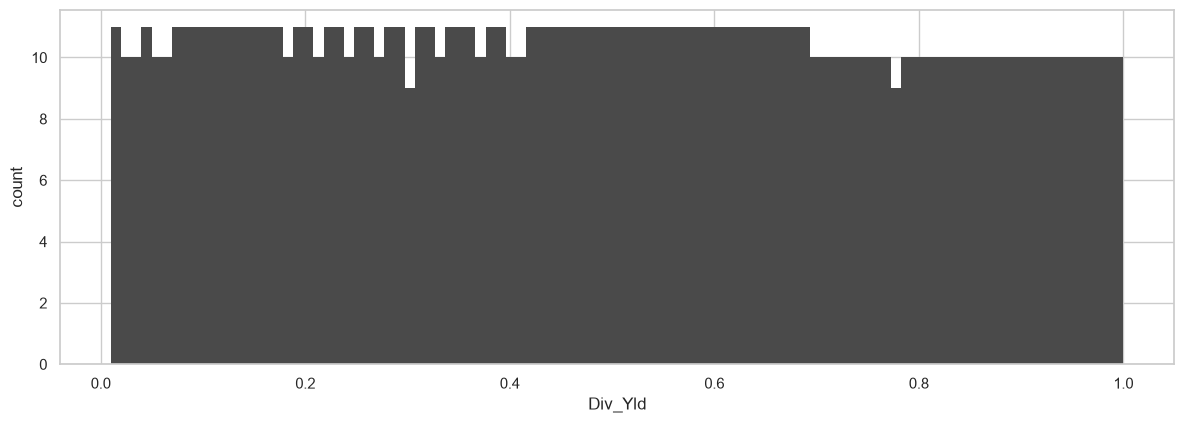

In [5]:
df_sub = data_ml[data_ml["date"] == "2000-02-29"]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12,10))
ax.hist(df_sub["Div_Yld"], bins=100, color="#4a4a4a", edgecolor="none")
ax.set_xlabel("Div_Yld")
ax.set_ylabel("count")

ax.set_aspect(0.03)
plt.tight_layout()
plt.show()

<p>The original lebls such as future returns are numerical and will be used for regression exercises, usually when the objective is to predict a scalar real number. Sometimes we might need to forecast categories like "buy", "hold", or "sell",
In order to perform this type of classification analysis we can create additional labels that are catgorical

</p>

In [6]:
data_ml["R1M_Usd_C"] = data_ml.groupby("date")["R1M_Usd"].transform(
    lambda x : x> x.median()
)
data_ml["R12M_Usd_C"] = data_ml.groupby("date")["R12M_Usd"].transform(
    lambda x : x> x.median()
)
#converting boolean/logical columns to categorical factors
bool_cols = data_ml.select_dtypes(include="bool").columns
data_ml[bool_cols] = data_ml[bool_cols].astype("category")
data_ml[["stock_id", "date","R1M_Usd_C", "R12M_Usd_C"]]

,stock_id,date,R1M_Usd_C,R12M_Usd_C
0,1,2000-01-31,False,True
1,1,2000-02-29,True,True
2,1,2000-03-31,True,True
3,1,2000-04-30,True,True
4,1,2000-05-31,False,True
...,...,...,...,...
268331,1212,2018-08-31,True,False
268332,1212,2018-09-30,False,False
268333,1212,2018-10-31,False,False
268334,1212,2018-11-30,False,False


In [7]:
#splitting our data into training set and test set
training_data = data_ml["date"] < "2014-01-15"
testing_data = data_ml["date"] >= "2014-01-15"

In [8]:
# 1. Get unique list of stock IDs
stock_ids = data_ml["stock_id"].astype("category").cat.categories.tolist()

# 2. Count data points per stock
stock_days = data_ml.groupby("stock_id").size().reset_index(name="nb")

# 3. Find stocks with full data history (maximum number of observations)
max_nb = stock_days["nb"].max()
stock_ids_short = stock_days.loc[stock_days["nb"] == max_nb, "stock_id"].tolist()

# 4. Filter and pivot returns into a wide Matrix (Dates x Stocks)
returns = (
    data_ml[data_ml["stock_id"].isin(stock_ids_short)][["date", "stock_id", "R1M_Usd"]]
    .pivot(index="date", columns="stock_id", values="R1M_Usd")
    .reset_index()
)

<h1><b>Simple Portfolio Sorts</b></h1>
This procedure is one of the most common procedure used. <i>Fama and French (1992)</i> The idea is relatively simple:

<p>
1. Rank Firms according to a particula criterion (e.g., size, book-to-market ratio)
<br>
2. Form <b><i>J</i></b> ≥ 2 portfolios (i.e the same groups) consisting of the same number of stocks, according to the ranking ( usually, <b><i>J</i></b>= 2, <b><i>J</i></b>= 3, <b><i>J</i></b>= 5 or <b><i>J</i></b>= 10 portfolios are built, based on the median, terciles, quintiles, or deciles)
<br>
3. the weight of stocks inside the portfolio is either uniform (equal weights) or proportional to market capitalisation;
<br>
4. At a future date (usually a month), report the returns of the portfolios. Then iterate the procedure until the chronological end of the sample is reached.
<br>
<br>
The outcome is a time series of portfolio returns for each grouping. An anomaly is identified if the t-test between the first (j=1) and the last group (j=J) unveils a significant difference in average returns.
</p>

<p>In the code below I compyued size portfolios - equally weighted: above versus below the median capitlisation. Accoding to the size anomaly, firms with below median market cap should usually earn higher returns
on average. This is verified whenever the orange bar in the plot is above the blue one.
</p>

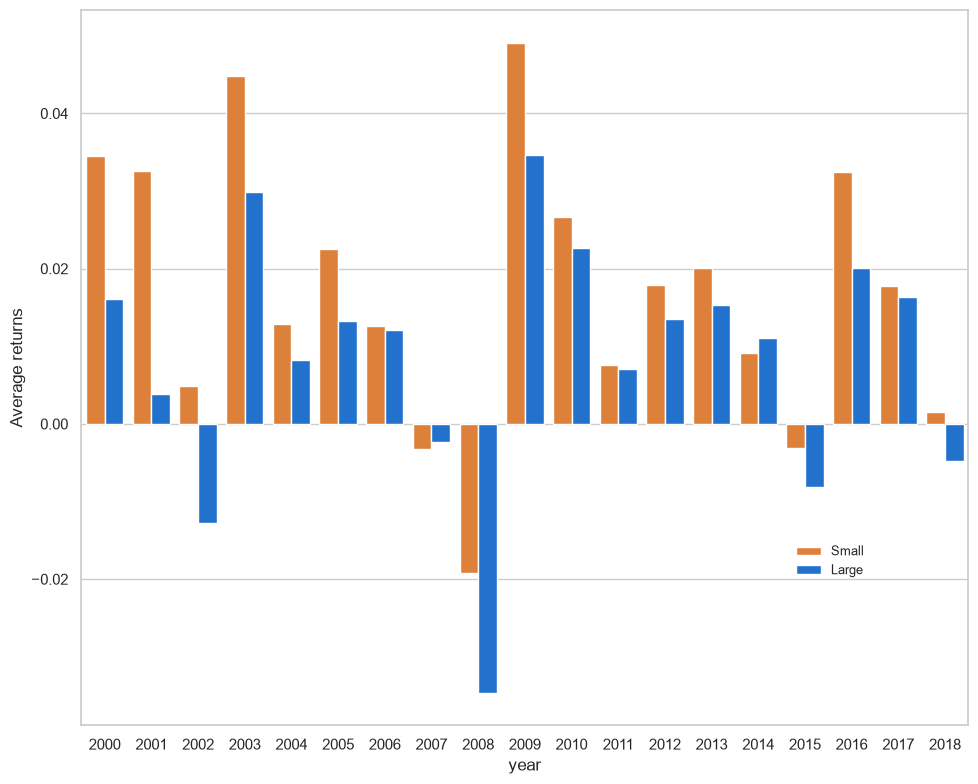

In [12]:
df_summary = (
    data_ml.assign(
        large = lambda x: x["Mkt_Cap_12M_Usd"] > x.groupby("date")["Mkt_Cap_12M_Usd"].transform("median"),
        year = lambda x: pd.to_datetime(x["date"]).dt.year
    )
    .groupby(["year", "large"])["R1M_Usd"]
    .mean()
    .reset_index(name="avg_return")
)

#Plotting
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# Dodge bar plot
sns.barplot(
    data=df_summary,
    x="year",
    y="avg_return",
    hue="large",
    palette=["#F87E1F", "#0570EA"],
    ax=ax
)

# Labeling & Legend Styling
ax.set_ylabel("Average returns")
ax.set_xlabel("year")

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Small", "Large"], loc=(0.8, 0.2), frameon=False, fontsize=9)
ax.set_box_aspect(1 / 1.24)

plt.tight_layout()
plt.show()